# SpaGE validation benchmark for Br8667

This notebook adapts the official SpaGE tutorial to the frozen Br8667 benchmark.

## Experiment

- **Reference:** Huuki snRNA-seq.
- **Spatial input:** Xenium Br8667 with the 210 frozen training genes.
- **Development truth:** 45 frozen validation genes.
- **Blind test:** not loaded or evaluated here.
- **Primary metric:** median gene-wise Spearman correlation across spatial cells.

SpaGE is not a neural network and has no epochs, training loss, or accuracy curve. It aligns the reference and spatial datasets using principal vectors and then predicts target genes from nearby reference cells.

## Original tutorial versus this notebook

The original tutorial:

1. normalizes scRNA-seq with log-CPM;
2. normalizes spatial counts to the median spatial library size;
3. validates SpaGE by leaving measured genes out;
4. predicts unmeasured spatial genes.

This notebook replaces tutorial leave-one-gene-out splitting with the fixed Br8667 `210/45/45` gene split.


## Before running

Place the SpaGE repository here:

```text
/users/mjabin/projects/GeneBridge/src/imputation/SpaGE
```

From the project root:

```bash
cd /users/mjabin/projects/GeneBridge/src/imputation
git clone https://github.com/asad14053/SpaGE.git
```

SpaGE runs on the CPU. A GPU is not required.


In [37]:
from pathlib import Path

# -----------------------------------------------------------------------------
# Project paths
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path("/users/mjabin/projects/GeneBridge")
BASE_DIR = PROJECT_ROOT / "data/processed/imputation_beta/Br8667"

SPAGE_REPO = PROJECT_ROOT / "src/imputation/SpaGE"

SEQ_PATH = (
    BASE_DIR
    / "seq_data_huuki_snrna_Br8667_vista.h5ad"
)

SPATIAL_TRAIN_PATH = (
    BASE_DIR
    / "benchmark/inputs/spatial_train_210genes.h5ad"
)

VALIDATION_TRUTH_PATH = (
    BASE_DIR
    / "benchmark/truth/validation_truth_45genes.h5ad"
)

VALIDATION_SPLIT_PATH = (
    BASE_DIR
    / "benchmark/splits/validation_genes_45.csv"
)

DEVELOPMENT_CELL_IDS_PATH = (
    BASE_DIR
    / "benchmark/splits/development_cell_ids.csv"
)

PREDICTION_DIR = (
    BASE_DIR
    / "benchmark/predictions"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs/imputation_beta/Br8667"
)

REPORT_DIR = (
    OUTPUT_ROOT
    / "validation/spage"
)

FIGURE_DIR = REPORT_DIR / "figures"

for directory in [
    PREDICTION_DIR,
    REPORT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# -----------------------------------------------------------------------------
# Experiment configuration
# -----------------------------------------------------------------------------
RUN_MODE = "full"  # Choose: "smoke" or "full"
RANDOM_SEED = 8667

# SpaGE paper used 30 PVs for osmFISH pairs and 50 for larger panels.
# Br8667 has up to 210 alignment genes, so 50 is a reasonable baseline.
N_PV = 50

# Original SpaGE preprocessing removes reference genes detected in fewer than
# 10 cells. We apply this criterion to alignment genes.
MIN_REFERENCE_DETECTED_CELLS = 10

# Smoke mode uses deterministic subsets only to verify the workflow.
SMOKE_REFERENCE_CELLS = 2_000
SMOKE_SPATIAL_CELLS = 5_000

N_SPATIAL_GENES_TO_PLOT = 4

if RUN_MODE not in {"smoke", "full"}:
    raise ValueError(
        "RUN_MODE must be either 'smoke' or 'full'."
    )

RUN_SUFFIX = (
    "_smoke"
    if RUN_MODE == "smoke"
    else ""
)

PREDICTION_PATH = (
    PREDICTION_DIR
    / (
        "spage_validation_predictions_45genes"
        f"{RUN_SUFFIX}.h5ad"
    )
)

print("Run mode:", RUN_MODE)
print("Requested principal vectors:", N_PV)
print("Prediction path:", PREDICTION_PATH)


Run mode: full
Requested principal vectors: 50
Prediction path: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/spage_validation_predictions_45genes.h5ad


## 1. Import packages and SpaGE


In [38]:
import inspect
import sys
import time
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import sparse
from scipy.stats import pearsonr, spearmanr
import sklearn

from IPython.display import display

np.random.seed(RANDOM_SEED)

if not SPAGE_REPO.exists():
    raise FileNotFoundError(
        "SpaGE repository was not found at:\n"
        f"{SPAGE_REPO}\n\n"
        "Clone it under src/imputation before continuing."
    )

# Add the repository root. It contains the internal SpaGE/ source folder.
if str(SPAGE_REPO) not in sys.path:
    sys.path.insert(
        0,
        str(SPAGE_REPO),
    )

from SpaGE.main import SpaGE

print("Python:", sys.version.split()[0])
print("AnnData:", ad.__version__ if hasattr(ad, "__version__") else "unknown")
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("SpaGE function:", inspect.signature(SpaGE))


Python: 3.9.23
AnnData: 0.9.2
NumPy: 1.24.4
SciPy: 1.10.1
scikit-learn: 1.6.1
SpaGE function: (Spatial_data, RNA_data, n_pv, genes_to_predict=None)


## 2. Helper functions


In [39]:
def row_sums(matrix):
    if sparse.issparse(matrix):
        return np.asarray(
            matrix.sum(axis=1)
        ).ravel()

    return np.asarray(matrix).sum(axis=1)


def matrix_to_dataframe(
    adata,
    genes,
    *,
    dtype=np.float32,
):
    genes = [str(gene) for gene in genes]

    positions = adata.var_names.get_indexer(
        genes
    )

    if np.any(positions < 0):
        missing = [
            genes[index]
            for index, position
            in enumerate(positions)
            if position < 0
        ]

        raise ValueError(
            f"Genes missing from AnnData: {missing[:20]}"
        )

    matrix = adata[:, genes].X

    if sparse.issparse(matrix):
        matrix = matrix.toarray()

    matrix = np.asarray(
        matrix,
        dtype=dtype,
    )

    return pd.DataFrame(
        matrix,
        index=adata.obs_names.astype(str),
        columns=genes,
    )


def normalize_reference_log_cpm(
    raw_counts,
):
    """SpaGE tutorial scRNA normalization: log1p CPM."""
    values = raw_counts.to_numpy(
        dtype=np.float32,
        copy=True,
    )

    library_sizes = values.sum(
        axis=1,
    )

    if np.any(library_sizes <= 0):
        raise ValueError(
            "Reference matrix contains zero-library cells."
        )

    normalized = np.log1p(
        (
            values
            / library_sizes[:, None]
        )
        * 1_000_000.0
    )

    return pd.DataFrame(
        normalized.astype(
            np.float32,
            copy=False,
        ),
        index=raw_counts.index.copy(),
        columns=raw_counts.columns.copy(),
    )


def normalize_spatial_input(
    raw_counts,
):
    """
    SpaGE tutorial spatial normalization:
    divide by input library size, scale by median library size, then log1p.
    """
    values = raw_counts.to_numpy(
        dtype=np.float32,
        copy=True,
    )

    library_sizes = values.sum(
        axis=1,
    )

    if np.any(library_sizes <= 0):
        raise ValueError(
            "Spatial input contains zero-library cells."
        )

    scale_factor = float(
        np.median(library_sizes)
    )

    normalized = np.log1p(
        (
            values
            / library_sizes[:, None]
        )
        * scale_factor
    )

    normalized_df = pd.DataFrame(
        normalized.astype(
            np.float32,
            copy=False,
        ),
        index=raw_counts.index.copy(),
        columns=raw_counts.columns.copy(),
    )

    return (
        normalized_df,
        library_sizes.astype(
            np.float32,
            copy=False,
        ),
        scale_factor,
    )


def normalize_hidden_truth(
    raw_truth,
    input_library_sizes,
    spatial_scale_factor,
):
    """
    Normalize hidden truth using size factors calculated only from the
    permitted spatial input genes.
    """
    values = raw_truth.to_numpy(
        dtype=np.float32,
        copy=True,
    )

    input_library_sizes = np.asarray(
        input_library_sizes,
        dtype=np.float32,
    )

    if values.shape[0] != input_library_sizes.shape[0]:
        raise ValueError(
            "Truth rows and input library sizes do not match."
        )

    normalized = np.log1p(
        (
            values
            / input_library_sizes[:, None]
        )
        * float(spatial_scale_factor)
    )

    return pd.DataFrame(
        normalized.astype(
            np.float32,
            copy=False,
        ),
        index=raw_truth.index.copy(),
        columns=raw_truth.columns.copy(),
    )


def safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[mask]
    y = y[mask]

    if (
        x.size < 3
        or np.allclose(x, x[0])
        or np.allclose(y, y[0])
    ):
        return np.nan

    result = spearmanr(x, y)

    return float(
        result.statistic
        if hasattr(result, "statistic")
        else result[0]
    )


def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[mask]
    y = y[mask]

    if (
        x.size < 3
        or np.allclose(x, x[0])
        or np.allclose(y, y[0])
    ):
        return np.nan

    result = pearsonr(x, y)

    return float(
        result.statistic
        if hasattr(result, "statistic")
        else result[0]
    )


def standardize_vector(values):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    mean = np.mean(values)
    std = np.std(values)

    if (
        not np.isfinite(std)
        or std <= 1e-12
    ):
        return np.full_like(
            values,
            np.nan,
            dtype=np.float64,
        )

    return (
        values - mean
    ) / std


def calculate_gene_metrics(
    observed,
    predicted,
):
    if not observed.index.equals(
        predicted.index
    ):
        raise ValueError(
            "Observed and predicted cell orders differ."
        )

    if list(observed.columns) != list(
        predicted.columns
    ):
        raise ValueError(
            "Observed and predicted gene orders differ."
        )

    records = []

    for gene in observed.columns:
        obs = observed[gene].to_numpy()
        pred = predicted[gene].to_numpy()

        obs_z = standardize_vector(obs)
        pred_z = standardize_vector(pred)

        valid_z = (
            np.isfinite(obs_z)
            & np.isfinite(pred_z)
        )

        if valid_z.any():
            mae_z = float(
                np.mean(
                    np.abs(
                        pred_z[valid_z]
                        - obs_z[valid_z]
                    )
                )
            )

            rmse_z = float(
                np.sqrt(
                    np.mean(
                        (
                            pred_z[valid_z]
                            - obs_z[valid_z]
                        )
                        ** 2
                    )
                )
            )
        else:
            mae_z = np.nan
            rmse_z = np.nan

        records.append(
            {
                "gene": gene,
                "spearman_across_cells":
                    safe_spearman(obs, pred),
                "pearson_across_cells":
                    safe_pearson(obs, pred),
                "mae_standardized":
                    mae_z,
                "rmse_standardized":
                    rmse_z,
                "observed_mean":
                    float(np.mean(obs)),
                "predicted_mean":
                    float(np.mean(pred)),
                "observed_variance":
                    float(np.var(obs)),
                "predicted_variance":
                    float(np.var(pred)),
                "observed_nonzero_fraction":
                    float(np.mean(obs > 0)),
                "predicted_positive_fraction":
                    float(np.mean(pred > 0)),
            }
        )

    return pd.DataFrame(records)


def calculate_pseudobulk_metrics(
    observed,
    predicted,
    metadata,
    group_column,
):
    if group_column not in metadata.columns:
        print(
            f"Skipping pseudobulk: "
            f"'{group_column}' is absent."
        )
        return pd.DataFrame()

    groups = (
        metadata.loc[
            observed.index,
            group_column,
        ]
        .astype(str)
    )

    observed_grouped = (
        observed
        .assign(_group=groups.values)
        .groupby("_group")
        .mean()
    )

    predicted_grouped = (
        predicted
        .assign(_group=groups.values)
        .groupby("_group")
        .mean()
    )

    common_groups = (
        observed_grouped.index
        .intersection(
            predicted_grouped.index
        )
    )

    records = []

    for gene in observed.columns:
        obs = observed_grouped.loc[
            common_groups,
            gene,
        ].to_numpy()

        pred = predicted_grouped.loc[
            common_groups,
            gene,
        ].to_numpy()

        records.append(
            {
                "gene": gene,
                "group_column": group_column,
                "n_groups": len(common_groups),
                "pseudobulk_spearman":
                    safe_spearman(obs, pred),
                "pseudobulk_pearson":
                    safe_pearson(obs, pred),
            }
        )

    return pd.DataFrame(records)


def first_existing_column(
    dataframe,
    candidates,
):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


## 3. Load the frozen benchmark data

The blind-test file is deliberately not loaded.


In [40]:
required_paths = [
    SEQ_PATH,
    SPATIAL_TRAIN_PATH,
    VALIDATION_TRUTH_PATH,
    VALIDATION_SPLIT_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

seq_data = ad.read_h5ad(
    SEQ_PATH
)

spatial_train = ad.read_h5ad(
    SPATIAL_TRAIN_PATH
)

validation_truth = ad.read_h5ad(
    VALIDATION_TRUTH_PATH
)

validation_split = pd.read_csv(
    VALIDATION_SPLIT_PATH
)

print("snRNA reference:", seq_data.shape)
print("Spatial training input:", spatial_train.shape)
print("Validation truth:", validation_truth.shape)


snRNA reference: (9897, 28907)
Spatial training input: (66164, 210)
Validation truth: (66164, 45)


## 4. Validate the split and align the benchmark cells


In [41]:
train_genes = (
    spatial_train.var_names
    .astype(str)
    .tolist()
)

validation_genes = (
    validation_truth.var_names
    .astype(str)
    .tolist()
)

seq_gene_set = set(
    seq_data.var_names.astype(str)
)

checks = {
    "training_genes_is_210":
        len(train_genes) == 210,
    "validation_genes_is_45":
        len(validation_genes) == 45,
    "train_validation_disjoint":
        set(train_genes).isdisjoint(
            validation_genes
        ),
    "all_training_genes_in_reference":
        set(train_genes).issubset(
            seq_gene_set
        ),
    "all_validation_genes_in_reference":
        set(validation_genes).issubset(
            seq_gene_set
        ),
    "spatial_truth_cells_match":
        spatial_train.obs_names.equals(
            validation_truth.obs_names
        ),
    "spatial_coordinates_present":
        "spatial" in spatial_train.obsm,
}

print("Benchmark checks:")

for name, passed in checks.items():
    print(f"  {name}: {passed}")

if not all(checks.values()):
    failed = [
        name
        for name, passed in checks.items()
        if not passed
    ]

    raise ValueError(
        f"Benchmark checks failed: {failed}"
    )


# Reuse the fixed development-cell list created for the benchmark.
if DEVELOPMENT_CELL_IDS_PATH.exists():
    development_cell_ids = (
        pd.read_csv(
            DEVELOPMENT_CELL_IDS_PATH
        )["cell_id"]
        .astype(str)
        .tolist()
    )

    missing_cells = (
        pd.Index(development_cell_ids)
        .difference(
            spatial_train.obs_names.astype(str)
        )
    )

    if len(missing_cells) > 0:
        raise ValueError(
            f"{len(missing_cells)} development cells "
            "are missing from spatial input."
        )

    spatial_train = spatial_train[
        development_cell_ids
    ].copy()

    validation_truth = validation_truth[
        development_cell_ids
    ].copy()

    print(
        "Reused fixed development-cell list:",
        len(development_cell_ids),
    )

else:
    spatial_totals = row_sums(
        spatial_train.X
    )

    keep_cells = spatial_totals > 0

    development_cell_ids = (
        spatial_train.obs_names[
            keep_cells
        ]
        .astype(str)
        .tolist()
    )

    spatial_train = spatial_train[
        development_cell_ids
    ].copy()

    validation_truth = validation_truth[
        development_cell_ids
    ].copy()

    pd.DataFrame(
        {"cell_id": development_cell_ids}
    ).to_csv(
        DEVELOPMENT_CELL_IDS_PATH,
        index=False,
    )

    print(
        "Created development-cell list:",
        len(development_cell_ids),
    )

assert spatial_train.obs_names.equals(
    validation_truth.obs_names
)

print("Aligned spatial cells:", spatial_train.n_obs)


Benchmark checks:
  training_genes_is_210: True
  validation_genes_is_45: True
  train_validation_disjoint: True
  all_training_genes_in_reference: True
  all_validation_genes_in_reference: True
  spatial_truth_cells_match: True
  spatial_coordinates_present: True
Reused fixed development-cell list: 66154
Aligned spatial cells: 66154


## 5. Apply deterministic smoke subsets

Smoke mode verifies that loading, normalization, SpaGE, prediction, saving, and evaluation all work. It is not a scientific result.


In [42]:
rng = np.random.default_rng(
    RANDOM_SEED
)

if RUN_MODE == "smoke":
    reference_count = min(
        SMOKE_REFERENCE_CELLS,
        seq_data.n_obs,
    )

    spatial_count = min(
        SMOKE_SPATIAL_CELLS,
        spatial_train.n_obs,
    )

    reference_indices = np.sort(
        rng.choice(
            seq_data.n_obs,
            size=reference_count,
            replace=False,
        )
    )

    spatial_indices = np.sort(
        rng.choice(
            spatial_train.n_obs,
            size=spatial_count,
            replace=False,
        )
    )

    seq_data = seq_data[
        reference_indices
    ].copy()

    selected_spatial_ids = (
        spatial_train.obs_names[
            spatial_indices
        ]
    )

    spatial_train = spatial_train[
        selected_spatial_ids
    ].copy()

    validation_truth = validation_truth[
        selected_spatial_ids
    ].copy()

    print(
        "Smoke reference nuclei:",
        seq_data.n_obs,
    )

    print(
        "Smoke spatial cells:",
        spatial_train.n_obs,
    )

else:
    print(
        "Full mode: using all retained cells."
    )


Full mode: using all retained cells.


## 6. Convert the required genes to count DataFrames

For validation, SpaGE needs only:

- the 210 spatial input genes for alignment;
- the 45 requested validation genes for prediction.

The other snRNA-seq genes are not used by the SpaGE function in this run. Subsetting them here is a memory optimization, not a new biological split.


In [43]:
required_reference_genes = list(
    dict.fromkeys(
        train_genes
        + validation_genes
    )
)

reference_raw = matrix_to_dataframe(
    seq_data,
    required_reference_genes,
)

spatial_raw = matrix_to_dataframe(
    spatial_train,
    train_genes,
)

validation_raw = matrix_to_dataframe(
    validation_truth,
    validation_genes,
)

print("Reference raw:", reference_raw.shape)
print("Spatial raw:", spatial_raw.shape)
print("Validation raw:", validation_raw.shape)

if not np.isfinite(
    reference_raw.to_numpy()
).all():
    raise ValueError(
        "Reference counts contain invalid values."
    )

if not np.isfinite(
    spatial_raw.to_numpy()
).all():
    raise ValueError(
        "Spatial counts contain invalid values."
    )

if (
    reference_raw.to_numpy() < 0
).any():
    raise ValueError(
        "Reference counts contain negative values."
    )

if (
    spatial_raw.to_numpy() < 0
).any():
    raise ValueError(
        "Spatial counts contain negative values."
    )


Reference raw: (9897, 255)
Spatial raw: (66154, 210)
Validation raw: (66154, 45)


## 7. Normalize like the SpaGE tutorial

- snRNA-seq: `log1p(count / cell total × 1,000,000)`
- spatial input: `log1p(count / cell total × median spatial cell total)`


In [44]:
# Remove reference cells with zero total across the required genes.
reference_keep = (
    reference_raw.sum(axis=1)
    > 0
)

print(
    "Reference cells removed because required-gene total was zero:",
    int((~reference_keep).sum()),
)

reference_raw = reference_raw.loc[
    reference_keep
].copy()

reference_normalized = (
    normalize_reference_log_cpm(
        reference_raw
    )
)

(
    spatial_normalized,
    spatial_input_library_sizes,
    spatial_scale_factor,
) = normalize_spatial_input(
    spatial_raw
)

validation_observed_normalized = (
    normalize_hidden_truth(
        validation_raw,
        spatial_input_library_sizes,
        spatial_scale_factor,
    )
)

print(
    "Spatial normalization scale factor:",
    spatial_scale_factor,
)

print(
    "Reference normalized:",
    reference_normalized.shape,
)

print(
    "Spatial normalized:",
    spatial_normalized.shape,
)


Reference cells removed because required-gene total was zero: 0
Spatial normalization scale factor: 549.0
Reference normalized: (9897, 255)
Spatial normalized: (66154, 210)


## 8. Select valid alignment genes

The original SpaGE preprocessing filters reference genes detected in fewer than 10 cells. Constant genes also cannot be standardized safely, so they are excluded from alignment.

All 45 validation genes remain prediction targets.


In [45]:
reference_detection_counts = (
    reference_raw[train_genes]
    > 0
).sum(axis=0)

reference_std = (
    reference_normalized[
        train_genes
    ]
    .std(axis=0, ddof=0)
)

spatial_std = (
    spatial_normalized[
        train_genes
    ]
    .std(axis=0, ddof=0)
)

alignment_table = pd.DataFrame(
    {
        "gene": train_genes,
        "reference_detected_cells": [
            int(reference_detection_counts[gene])
            for gene in train_genes
        ],
        "reference_std": [
            float(reference_std[gene])
            for gene in train_genes
        ],
        "spatial_std": [
            float(spatial_std[gene])
            for gene in train_genes
        ],
    }
)

alignment_table[
    "passes_reference_detection"
] = (
    alignment_table[
        "reference_detected_cells"
    ]
    >= MIN_REFERENCE_DETECTED_CELLS
)

alignment_table[
    "passes_variance"
] = (
    np.isfinite(
        alignment_table["reference_std"]
    )
    & np.isfinite(
        alignment_table["spatial_std"]
    )
    & (
        alignment_table["reference_std"]
        > 1e-8
    )
    & (
        alignment_table["spatial_std"]
        > 1e-8
    )
)

alignment_table[
    "used_for_alignment"
] = (
    alignment_table[
        "passes_reference_detection"
    ]
    & alignment_table[
        "passes_variance"
    ]
)

alignment_genes = (
    alignment_table.loc[
        alignment_table[
            "used_for_alignment"
        ],
        "gene",
    ]
    .astype(str)
    .tolist()
)

ALIGNMENT_TABLE_PATH = (
    REPORT_DIR
    / (
        "15_spage_alignment_genes"
        f"{RUN_SUFFIX}.csv"
    )
)

alignment_table.to_csv(
    ALIGNMENT_TABLE_PATH,
    index=False,
)

print(
    "Frozen training genes:",
    len(train_genes),
)

print(
    "Genes retained for SpaGE alignment:",
    len(alignment_genes),
)

print(
    "Genes excluded from alignment:",
    len(train_genes)
    - len(alignment_genes),
)

if len(alignment_genes) < 2:
    raise ValueError(
        "Too few valid SpaGE alignment genes."
    )

display(
    alignment_table[
        ~alignment_table[
            "used_for_alignment"
        ]
    ].head(20)
)


Frozen training genes: 210
Genes retained for SpaGE alignment: 210
Genes excluded from alignment: 0


,gene,reference_detected_cells,reference_std,spatial_std,passes_reference_detection,passes_variance,used_for_alignment


## 9. Build the exact SpaGE inputs

SpaGE expects pandas DataFrames in **cells × genes** orientation.

- `Spatial_data`: spatial cells × alignment genes
- `RNA_data`: reference cells × (alignment genes + validation genes)
- `genes_to_predict`: the 45 validation genes


In [46]:
spage_spatial_input = (
    spatial_normalized[
        alignment_genes
    ]
    .astype(np.float32)
)

spage_reference_input = (
    reference_normalized[
        alignment_genes
        + validation_genes
    ]
    .astype(np.float32)
)

effective_n_pv = min(
    N_PV,
    len(alignment_genes),
    spage_reference_input.shape[0],
    spage_spatial_input.shape[0],
)

if effective_n_pv < 2:
    raise ValueError(
        f"Effective n_pv is too small: "
        f"{effective_n_pv}"
    )

print("SpaGE spatial input:", spage_spatial_input.shape)
print("SpaGE reference input:", spage_reference_input.shape)
print("Validation targets:", len(validation_genes))
print("Effective n_pv:", effective_n_pv)

print(
    "Shared alignment genes:",
    len(
        set(spage_spatial_input.columns)
        & set(spage_reference_input.columns)
    ),
)


SpaGE spatial input: (66154, 210)
SpaGE reference input: (9897, 255)
Validation targets: 45
Effective n_pv: 50
Shared alignment genes: 210


## 10. Run SpaGE

SpaGE is a single CPU computation. There are no epochs or training-loss curves.


In [47]:
prediction_start = time.time()

with warnings.catch_warnings():
    warnings.simplefilter(
        "default"
    )

    validation_prediction = SpaGE(
        Spatial_data=spage_spatial_input,
        RNA_data=spage_reference_input,
        n_pv=effective_n_pv,
        genes_to_predict=validation_genes,
    )

prediction_seconds = (
    time.time()
    - prediction_start
)

# The original function returns a DataFrame with a new RangeIndex.
validation_prediction.index = (
    spage_spatial_input.index.copy()
)

validation_prediction = (
    validation_prediction[
        validation_genes
    ]
    .astype(np.float32)
)

print(
    "Prediction shape:",
    validation_prediction.shape,
)

print(
    f"SpaGE completed in "
    f"{prediction_seconds / 60:.2f} minutes."
)

if not np.isfinite(
    validation_prediction.to_numpy()
).all():
    raise ValueError(
        "SpaGE predictions contain NaN or infinity."
    )


Prediction shape: (66154, 45)
SpaGE completed in 0.28 minutes.


## 11. Save validation predictions


In [48]:
prediction_adata = ad.AnnData(
    X=validation_prediction.to_numpy(
        dtype=np.float32,
    ),
    obs=spatial_train.obs.loc[
        validation_prediction.index
    ].copy(),
    var=validation_truth[
        :,
        validation_genes,
    ].var.copy(),
)

prediction_adata.obsm["spatial"] = (
    spatial_train[
        validation_prediction.index
    ].obsm["spatial"].copy()
)

prediction_adata.uns[
    "method"
] = "SpaGE"

prediction_adata.uns[
    "benchmark_role"
] = "validation_prediction"

prediction_adata.uns[
    "run_mode"
] = RUN_MODE

prediction_adata.uns[
    "requested_n_pv"
] = int(N_PV)

prediction_adata.uns[
    "effective_n_pv"
] = int(effective_n_pv)

prediction_adata.uns[
    "alignment_gene_count"
] = int(len(alignment_genes))

prediction_adata.uns[
    "prediction_scale"
] = (
    "weighted average of reference log1p CPM"
)

prediction_adata.write_h5ad(
    PREDICTION_PATH,
    compression="gzip",
)

print("Saved:")
print(PREDICTION_PATH)


Saved:
/users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/spage_validation_predictions_45genes.h5ad


## 12. Evaluate the 45 held-out validation genes

The primary metric is gene-wise Spearman correlation because SpaGE predicts reference-normalized expression while measured truth is spatial-normalized expression.

Standardized MAE and RMSE compare spatial pattern shape after independently standardizing each gene.


In [49]:
gene_metrics = calculate_gene_metrics(
    observed=validation_observed_normalized[
        validation_genes
    ],
    predicted=validation_prediction[
        validation_genes
    ],
)

merge_columns = [
    column
    for column in [
        "gene",
        "expression_stratum",
        "expression_stratum_number",
        "mean_expression",
        "detection_fraction",
    ]
    if column in validation_split.columns
]

if merge_columns:
    gene_metrics = gene_metrics.merge(
        validation_split[
            merge_columns
        ],
        on="gene",
        how="left",
    )

GENE_METRICS_PATH = (
    REPORT_DIR
    / (
        "15_spage_validation_gene_metrics"
        f"{RUN_SUFFIX}.csv"
    )
)

gene_metrics.to_csv(
    GENE_METRICS_PATH,
    index=False,
)

summary = pd.DataFrame(
    [
        {
            "metric": "run_mode",
            "value": RUN_MODE,
        },
        {
            "metric": "n_spatial_cells",
            "value": validation_prediction.shape[0],
        },
        {
            "metric": "n_reference_cells",
            "value": spage_reference_input.shape[0],
        },
        {
            "metric": "alignment_genes",
            "value": len(alignment_genes),
        },
        {
            "metric": "effective_n_pv",
            "value": effective_n_pv,
        },
        {
            "metric": "n_validation_genes",
            "value": len(validation_genes),
        },
        {
            "metric": "median_spearman_across_genes",
            "value": gene_metrics[
                "spearman_across_cells"
            ].median(skipna=True),
        },
        {
            "metric": "median_pearson_across_genes",
            "value": gene_metrics[
                "pearson_across_cells"
            ].median(skipna=True),
        },
        {
            "metric": "median_mae_standardized",
            "value": gene_metrics[
                "mae_standardized"
            ].median(skipna=True),
        },
        {
            "metric": "median_rmse_standardized",
            "value": gene_metrics[
                "rmse_standardized"
            ].median(skipna=True),
        },
        {
            "metric": "prediction_seconds",
            "value": prediction_seconds,
        },
    ]
)

SUMMARY_PATH = (
    REPORT_DIR
    / (
        "15_spage_validation_summary"
        f"{RUN_SUFFIX}.csv"
    )
)

summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

print("Validation summary:")
display(summary)

print("\nHighest validation Spearman:")
display(
    gene_metrics.sort_values(
        "spearman_across_cells",
        ascending=False,
    ).head(10)
)

print("\nLowest validation Spearman:")
display(
    gene_metrics.sort_values(
        "spearman_across_cells",
        ascending=True,
    ).head(10)
)

print("\nSaved:")
print(GENE_METRICS_PATH)
print(SUMMARY_PATH)


Validation summary:


,metric,value
0,run_mode,full
1,n_spatial_cells,66154
2,n_reference_cells,9897
3,alignment_genes,210
4,effective_n_pv,50
5,n_validation_genes,45
6,median_spearman_across_genes,0.385279
7,median_pearson_across_genes,0.450554
8,median_mae_standardized,0.69812
9,median_rmse_standardized,1.048281



Highest validation Spearman:


,gene,spearman_across_cells,pearson_across_cells,mae_standardized,rmse_standardized,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
36,RNASE1,0.718274,0.793276,0.438130,0.642999,0.952340,1.337858,1.310391,1.897962,0.499970,0.957931,S5_highest,5,3.385866,0.499894
15,ENC1,0.689114,0.759024,0.534402,0.694228,1.205387,5.466255,1.178107,6.960197,0.681561,1.000000,S5_highest,5,8.160025,0.681458
12,CSMD1,0.680864,0.730335,0.556742,0.734391,0.716655,8.021633,0.734361,5.647307,0.489404,1.000000,S5_highest,5,3.481564,0.489330
10,CHST1,0.626396,0.645037,0.597908,0.842570,0.606256,2.043034,0.463962,3.541328,0.518124,0.984929,S4_high,4,2.071097,0.518046
21,KIF1A,0.618684,0.623206,0.671988,0.868095,1.426432,5.704282,0.618960,6.206550,0.833222,1.000000,S5_highest,5,5.834047,0.833097
18,GRIN2A,0.600621,0.599295,0.652571,0.895215,0.225049,5.690351,0.169687,11.169854,0.272168,1.000000,S3_medium,3,0.672800,0.272127
14,EGR3,0.574029,0.717364,0.499133,0.751846,0.446595,1.366897,0.385055,3.385955,0.413656,0.862926,S4_high,4,1.594090,0.413593
2,ALCAM,0.564774,0.547396,0.703511,0.951424,0.611775,5.277004,0.459997,7.765259,0.532303,1.000000,S4_high,4,1.588916,0.532223
31,OGA,0.541619,0.529925,0.736514,0.969613,1.346153,5.991800,0.536826,4.258078,0.845164,1.000000,S5_highest,5,5.152765,0.845037
11,CLDN5,0.537257,0.800477,0.284541,0.631701,0.291607,1.130896,0.488934,5.472192,0.180019,0.692339,S3_medium,3,0.770292,0.179992



Lowest validation Spearman:


,gene,spearman_across_cells,pearson_across_cells,mae_standardized,rmse_standardized,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
28,MTRNR2L12,-0.381674,-0.367059,1.394283,1.653517,3.768426,7.329771,0.940759,1.661323,0.998005,1.000000,S5_highest,5,47.485172,0.997990
41,THEMIS,0.085970,0.077681,0.681609,1.358174,0.013170,0.837370,0.010953,1.141796,0.020029,0.940835,S1_lowest,1,0.021386,0.020026
44,ZP3,0.102332,0.034965,0.893933,1.389270,0.072899,0.428705,0.053796,0.268338,0.113946,0.677964,S1_lowest,1,0.125304,0.113929
39,SMIM32,0.111575,0.248772,0.698568,1.225747,0.020387,0.057070,0.023085,0.014960,0.025456,0.250113,S1_lowest,1,0.059594,0.025452
20,IGFBP6,0.157749,0.062018,0.895101,1.369658,0.079876,0.539101,0.073816,0.263776,0.109215,0.815491,S1_lowest,1,0.138313,0.109198
43,TRABD2A,0.164618,0.221532,0.607697,1.247772,0.024410,0.558936,0.019803,0.927737,0.035765,0.682317,S1_lowest,1,0.045401,0.035760
42,TIMP1,0.174132,0.263980,0.722627,1.213277,0.071988,0.199457,0.072517,0.086671,0.083109,0.560359,S1_lowest,1,0.102719,0.083097
30,NXPH4,0.177847,0.320792,0.424953,1.165511,0.021474,0.058156,0.019633,0.043847,0.027874,0.203253,S1_lowest,1,0.042545,0.027870
16,FILIP1,0.210793,0.267628,0.815477,1.210266,0.160326,1.038187,0.167741,0.752075,0.175122,0.948197,S2_low,2,0.315305,0.175095
8,CALB2,0.211862,0.751637,0.310400,0.704787,0.122714,0.264952,0.226688,0.726110,0.093297,0.500469,S3_medium,3,0.733163,0.093283



Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_gene_metrics.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_summary.csv


## 13. Pseudobulk evaluation


In [50]:
celltype_column = first_existing_column(
    spatial_train.obs,
    [
        "scClassify",
        "cell_type_annotation",
        "cell_type",
    ],
)

layer_column = first_existing_column(
    spatial_train.obs,
    [
        "layer_annotation",
        "layer",
        "Layer",
    ],
)

print("Cell-type column:", celltype_column)
print("Layer column:", layer_column)

if celltype_column is not None:
    celltype_metrics = (
        calculate_pseudobulk_metrics(
            observed=validation_observed_normalized,
            predicted=validation_prediction,
            metadata=spatial_train.obs,
            group_column=celltype_column,
        )
    )
else:
    celltype_metrics = pd.DataFrame()

if layer_column is not None:
    layer_metrics = (
        calculate_pseudobulk_metrics(
            observed=validation_observed_normalized,
            predicted=validation_prediction,
            metadata=spatial_train.obs,
            group_column=layer_column,
        )
    )
else:
    layer_metrics = pd.DataFrame()

CELLTYPE_METRICS_PATH = (
    REPORT_DIR
    / (
        "15_spage_validation_celltype_pseudobulk"
        f"{RUN_SUFFIX}.csv"
    )
)

LAYER_METRICS_PATH = (
    REPORT_DIR
    / (
        "15_spage_validation_layer_pseudobulk"
        f"{RUN_SUFFIX}.csv"
    )
)

celltype_metrics.to_csv(
    CELLTYPE_METRICS_PATH,
    index=False,
)

layer_metrics.to_csv(
    LAYER_METRICS_PATH,
    index=False,
)

if not celltype_metrics.empty:
    print("\nMedian cell-type pseudobulk metrics:")
    display(
        celltype_metrics[
            [
                "pseudobulk_spearman",
                "pseudobulk_pearson",
            ]
        ].median(numeric_only=True)
    )

if not layer_metrics.empty:
    print("\nMedian layer pseudobulk metrics:")
    display(
        layer_metrics[
            [
                "pseudobulk_spearman",
                "pseudobulk_pearson",
            ]
        ].median(numeric_only=True)
    )


Cell-type column: scClassify
Layer column: layer_annotation

Median cell-type pseudobulk metrics:


pseudobulk_spearman    0.750000
pseudobulk_pearson     0.890653
dtype: float64


Median layer pseudobulk metrics:


pseudobulk_spearman    0.892857
pseudobulk_pearson     0.924776
dtype: float64

## 14. Validation figures


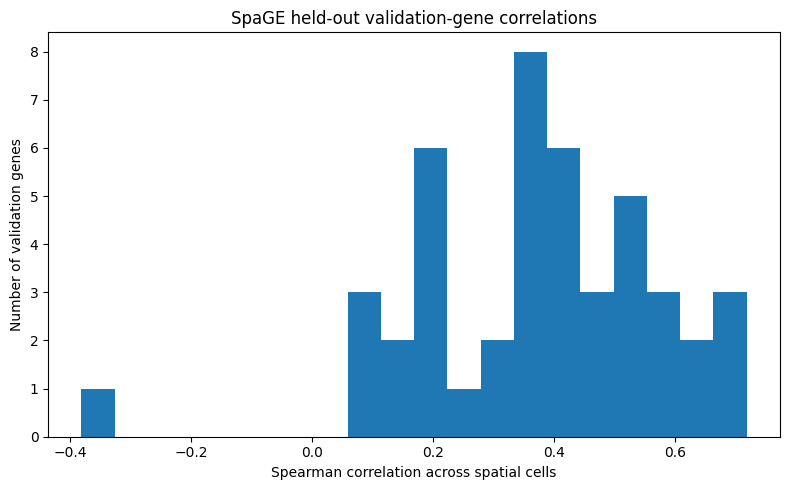

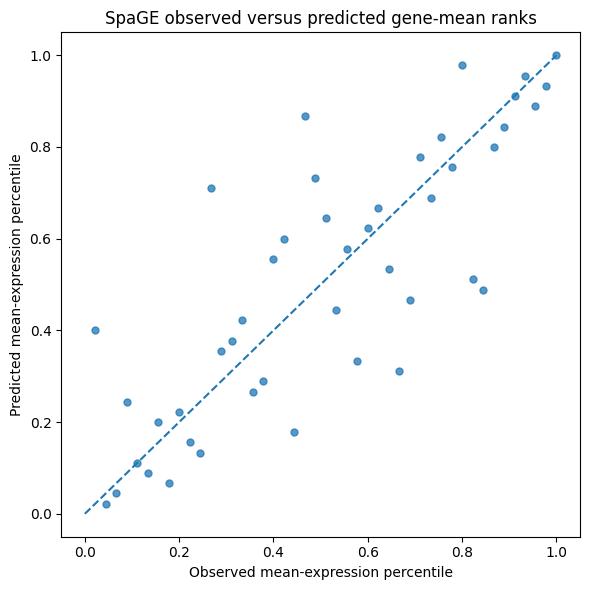

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_spage_validation_spearman_histogram.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_spage_observed_vs_predicted_mean_ranks.png


In [51]:
# Gene-wise Spearman distribution
plt.figure(figsize=(8, 5))

plt.hist(
    gene_metrics[
        "spearman_across_cells"
    ].dropna(),
    bins=20,
)

plt.xlabel(
    "Spearman correlation across spatial cells"
)
plt.ylabel(
    "Number of validation genes"
)
plt.title(
    "SpaGE held-out validation-gene correlations"
)
plt.tight_layout()

SPEARMAN_FIGURE_PATH = (
    FIGURE_DIR
    / (
        "15_spage_validation_spearman_histogram"
        f"{RUN_SUFFIX}.png"
    )
)

plt.savefig(
    SPEARMAN_FIGURE_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close()


# Observed versus predicted mean rank.
mean_table = gene_metrics.copy()

mean_table[
    "observed_mean_rank"
] = mean_table[
    "observed_mean"
].rank(pct=True)

mean_table[
    "predicted_mean_rank"
] = mean_table[
    "predicted_mean"
].rank(pct=True)

plt.figure(figsize=(6, 6))

plt.scatter(
    mean_table[
        "observed_mean_rank"
    ],
    mean_table[
        "predicted_mean_rank"
    ],
    s=25,
    alpha=0.75,
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel(
    "Observed mean-expression percentile"
)
plt.ylabel(
    "Predicted mean-expression percentile"
)
plt.title(
    "SpaGE observed versus predicted gene-mean ranks"
)
plt.tight_layout()

MEAN_RANK_FIGURE_PATH = (
    FIGURE_DIR
    / (
        "15_spage_observed_vs_predicted_mean_ranks"
        f"{RUN_SUFFIX}.png"
    )
)

plt.savefig(
    MEAN_RANK_FIGURE_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close()

print("Saved:")
print(SPEARMAN_FIGURE_PATH)
print(MEAN_RANK_FIGURE_PATH)


Validation genes selected for spatial maps: ['RNASE1', 'ENC1', 'MBP', 'HLA-B']


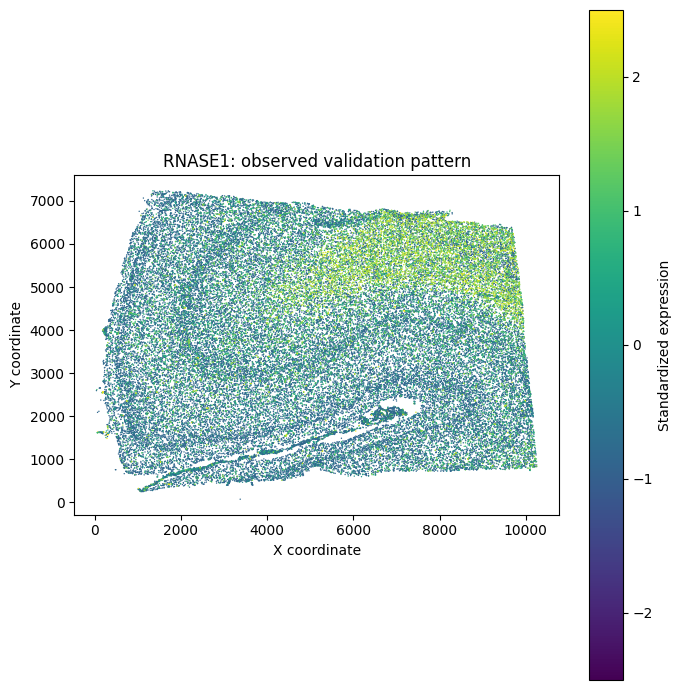

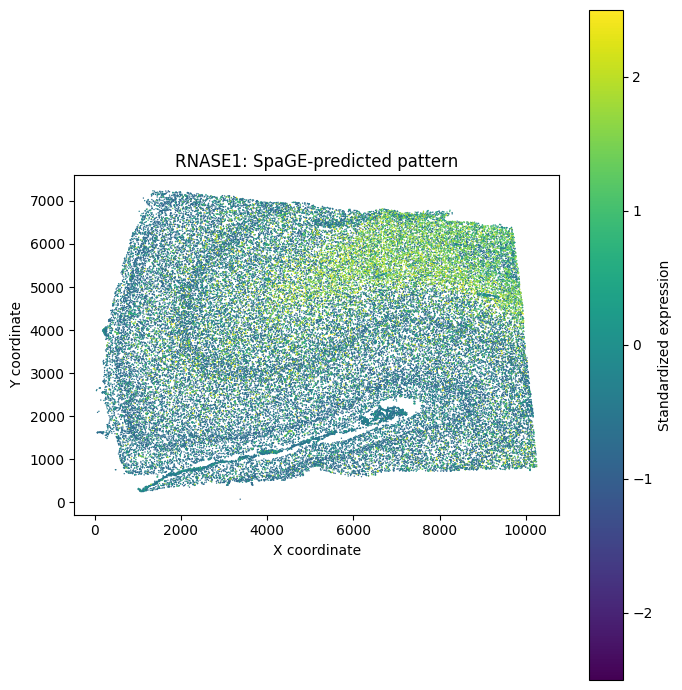

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_RNASE1_observed.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_RNASE1_predicted.png


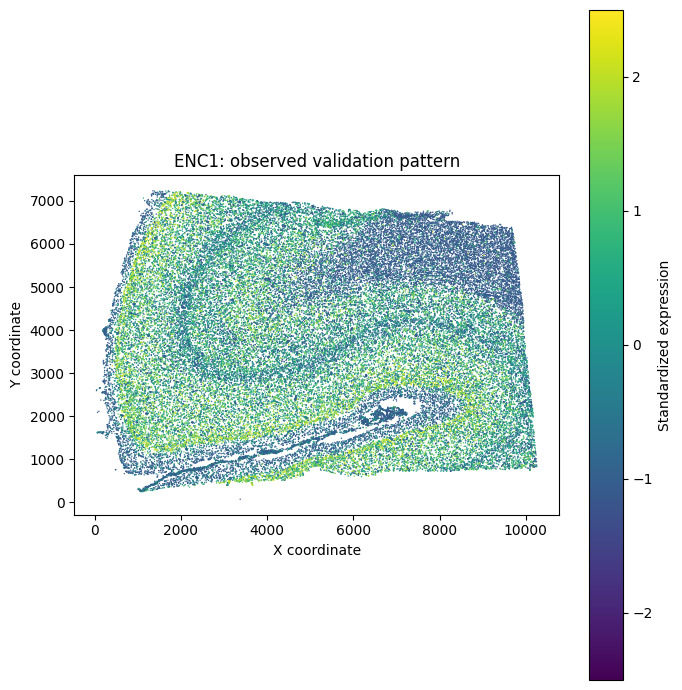

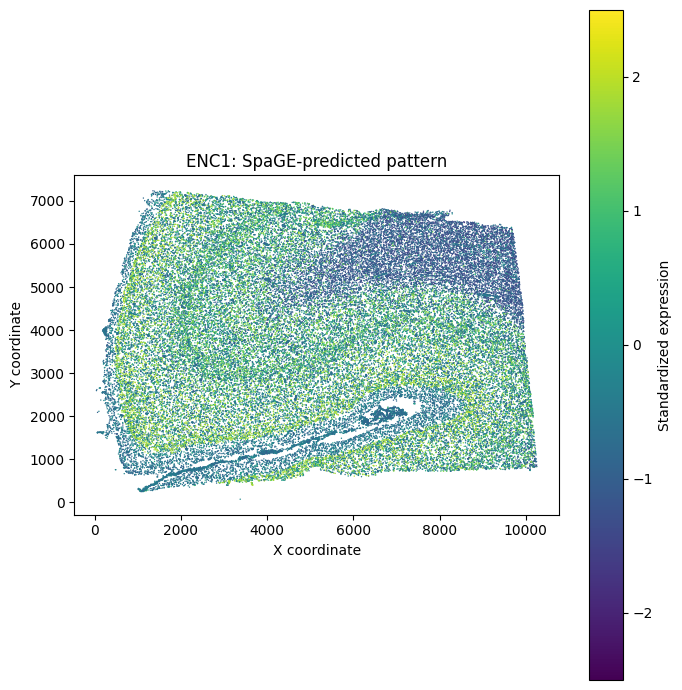

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_ENC1_observed.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_ENC1_predicted.png


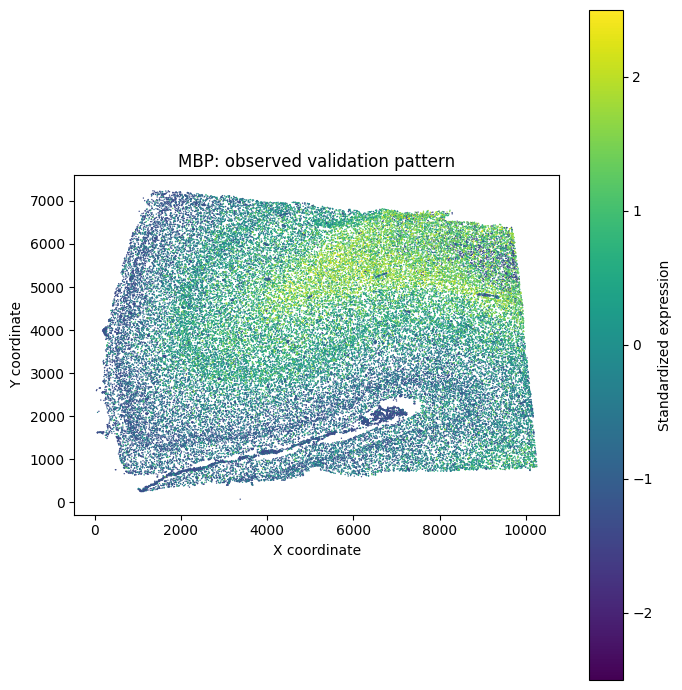

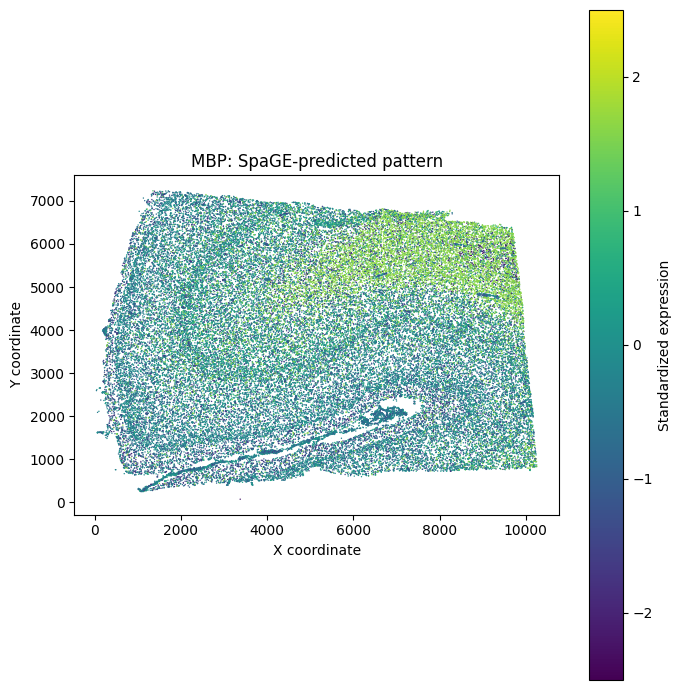

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_MBP_observed.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_MBP_predicted.png


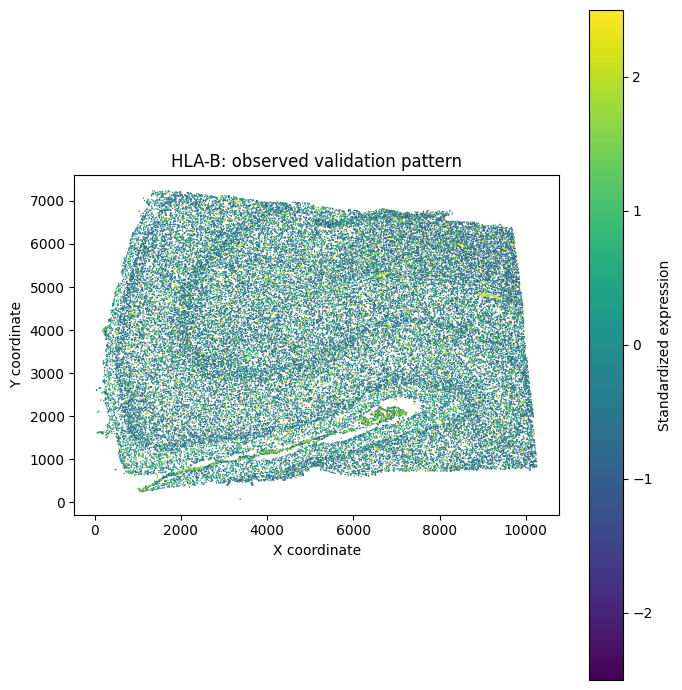

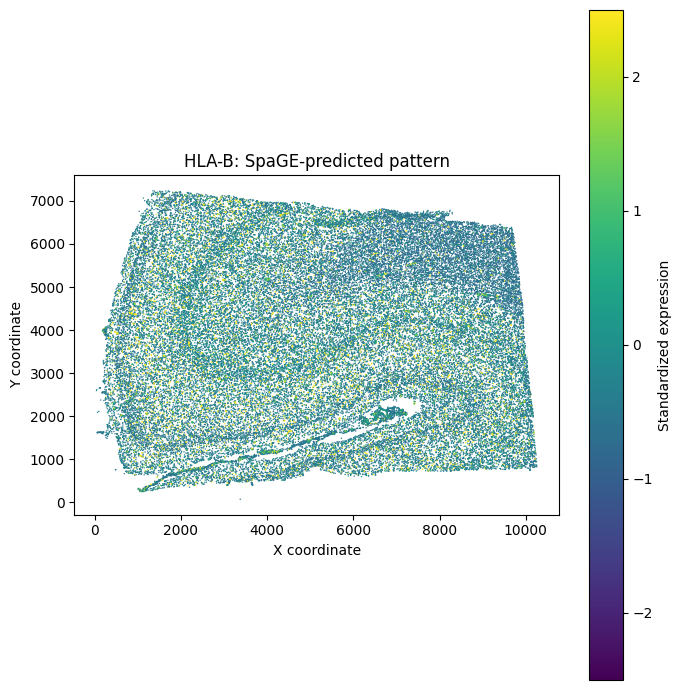

/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_HLA-B_observed.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_HLA-B_predicted.png


In [52]:
# Select examples using observed variance, not prediction performance.
spatial_examples = (
    gene_metrics.sort_values(
        "observed_variance",
        ascending=False,
    )
    .head(
        N_SPATIAL_GENES_TO_PLOT
    )["gene"]
    .astype(str)
    .tolist()
)

coordinates = np.asarray(
    spatial_train[
        validation_prediction.index
    ].obsm["spatial"]
)

x_coordinate = coordinates[:, 0]
y_coordinate = coordinates[:, 1]

print(
    "Validation genes selected for spatial maps:",
    spatial_examples,
)

for gene in spatial_examples:
    observed_values = standardize_vector(
        validation_observed_normalized[
            gene
        ].to_numpy()
    )

    predicted_values = standardize_vector(
        validation_prediction[
            gene
        ].to_numpy()
    )

    observed_values = np.clip(
        observed_values,
        -2.5,
        2.5,
    )

    predicted_values = np.clip(
        predicted_values,
        -2.5,
        2.5,
    )

    plt.figure(figsize=(7, 7))

    scatter = plt.scatter(
        x_coordinate,
        y_coordinate,
        c=observed_values,
        s=1,
        linewidths=0,
        rasterized=True,
        vmin=-2.5,
        vmax=2.5,
    )

    plt.gca().set_aspect(
        "equal"
    )
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(
        f"{gene}: observed validation pattern"
    )
    plt.colorbar(
        scatter,
        label="Standardized expression",
    )
    plt.tight_layout()

    observed_path = (
        FIGURE_DIR
        / (
            f"15_{gene}_observed"
            f"{RUN_SUFFIX}.png"
        )
    )

    plt.savefig(
        observed_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    plt.figure(figsize=(7, 7))

    scatter = plt.scatter(
        x_coordinate,
        y_coordinate,
        c=predicted_values,
        s=1,
        linewidths=0,
        rasterized=True,
        vmin=-2.5,
        vmax=2.5,
    )

    plt.gca().set_aspect(
        "equal"
    )
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.title(
        f"{gene}: SpaGE-predicted pattern"
    )
    plt.colorbar(
        scatter,
        label="Standardized expression",
    )
    plt.tight_layout()

    predicted_path = (
        FIGURE_DIR
        / (
            f"15_{gene}_predicted"
            f"{RUN_SUFFIX}.png"
        )
    )

    plt.savefig(
        predicted_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    print(observed_path)
    print(predicted_path)


## 15. Output inventory


In [53]:
created_outputs = [
    PREDICTION_PATH,
    ALIGNMENT_TABLE_PATH,
    GENE_METRICS_PATH,
    SUMMARY_PATH,
    CELLTYPE_METRICS_PATH,
    LAYER_METRICS_PATH,
    SPEARMAN_FIGURE_PATH,
    MEAN_RANK_FIGURE_PATH,
]

print("=" * 100)
print("SpaGE Br8667 validation workflow completed")
print("=" * 100)

for path in created_outputs:
    print(
        f"{'EXISTS' if path.exists() else 'MISSING'}: "
        f"{path}"
    )

print(
    "\nThis notebook did not load or evaluate "
    "the 45 blind test genes."
)

if RUN_MODE == "smoke":
    print(
        "\nThis was a smoke test. Restart the kernel, "
        "set RUN_MODE='full', and rerun all cells "
        "for the scientific validation result."
    )


SpaGE Br8667 validation workflow completed
EXISTS: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/spage_validation_predictions_45genes.h5ad
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_alignment_genes.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_gene_metrics.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_summary.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_celltype_pseudobulk.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/15_spage_validation_layer_pseudobulk.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/spage/figures/15_spage_validation_spearman_histogram.png
EXISTS: /users/mjabin/projects/GeneBrid

## Next benchmark step

After the full validation run:

1. compare SpaGE validation Spearman with gimVI and VISTA;
2. freeze `N_PV` and all preprocessing decisions;
3. combine the 210 training genes with the 45 validation genes;
4. rerun SpaGE using 255 spatial input genes;
5. evaluate once on the 45 blind test genes.

Do not inspect the blind test while selecting `N_PV`.
